In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── run this ONCE at the top, after loading ──
df_raw = pd.read_excel("student_performance_batchwise_2018_2025.xlsx")

df = df_raw.copy()   # fresh copy every run

print(df.shape)           # should be (1792, 13)


(1792, 13)


In [159]:
print(df.dtypes)

Student_ID           object
Student_Name         object
Batch                 int64
Semester              int64
Year                  int64
Mid1                float64
Mid2                float64
Internals           float64
EndTerm             float64
Attendance          float64
Total_Marks         float64
SGPA                float64
Performance_Type     object
dtype: object


In [160]:
print(df.isnull().sum())  # confirm no nulls

Student_ID          0
Student_Name        0
Batch               0
Semester            0
Year                0
Mid1                0
Mid2                0
Internals           0
EndTerm             0
Attendance          0
Total_Marks         0
SGPA                0
Performance_Type    0
dtype: int64


In [161]:
# How many unique students?
print(df['Student_ID'].nunique())  # expect ~224

224


In [162]:
# Does every student have exactly 8 semesters?
sem_counts = df.groupby('Student_ID')['Semester'].count()
print(sem_counts.value_counts())  # should be all 8s

Semester
8    224
Name: count, dtype: int64


In [163]:
# Performance type distribution
print(df['Performance_Type'].value_counts(normalize=True).round(3))

Performance_Type
Average              0.545
Low_Performer        0.179
Consistent_Topper    0.152
Late_Bloomer         0.125
Name: proportion, dtype: float64


### Hypothesis

#### Student performance shows a noticeable dip in the middle semesters (especially Sem 4–5), and this dip can be identified by comparing each semester’s SGPA with the student’s usual performance level. We expect that a personalized, past-based (rolling) approach will detect these dips more realistically than a full-history method.

### Dip Phase — Finding the reality of students when THEY gets a DIP in Results


#### Step 1 — Finding Whole Population's SPGA mean SEM wise

Semester
1    6.809107
2    6.857946
3    6.954777
4    6.764955
5    6.698482
6    7.103705
7    7.231562
8    7.302009
Name: SGPA, dtype: float64


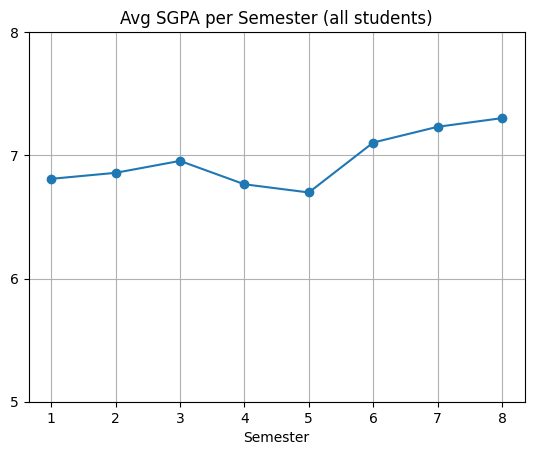

In [164]:
# Just look at the average SGPA per semester across everyone
sem_avg = df.groupby('Semester')['SGPA'].mean()
print(sem_avg)

# Plot it — your eyes will tell you if there's a dip
sem_avg.plot(marker='o', title='Avg SGPA per Semester (all students)')
plt.xticks(range(1, 9))
plt.yticks(range(5, 9))
plt.grid(True)
plt.show()

### Each student's own average SGPA across all 8 sems

In [165]:
df_full = df.copy()

# Personal stats
df_full['Personal_Avg'] = df_full.groupby('Student_ID')['SGPA'].transform('mean')
df_full['Student_STD'] = df_full.groupby('Student_ID')['SGPA'].transform('std')


df_full['Is_Dip_Full'] = df_full['SGPA'] < (df_full['Personal_Avg'] - df_full['Student_STD'])


df_full.head(5)

,Student_ID,Student_Name,Batch,Semester,Year,Mid1,Mid2,Internals,EndTerm,Attendance,Total_Marks,SGPA,Performance_Type,Personal_Avg,Student_STD,Is_Dip_Full
0,S0001,Neha Pal,2018,1,2018,5.39,7.29,8.88,58.08,73.8,50.60,4.93,Low_Performer,5.15625,0.533477,False
1,S0001,Neha Pal,2018,2,2018,7.01,7.03,13.11,55.69,68.9,55.00,5.38,Low_Performer,5.15625,0.533477,False
2,S0001,Neha Pal,2018,3,2019,7.35,6.11,8.07,60.64,68.3,51.86,4.94,Low_Performer,5.15625,0.533477,False
3,S0001,Neha Pal,2018,4,2019,5.82,5.71,8.71,52.67,72.9,46.57,4.92,Low_Performer,5.15625,0.533477,False
4,S0001,Neha Pal,2018,5,2020,6.63,4.54,8.52,60.58,71.2,49.98,4.86,Low_Performer,5.15625,0.533477,False


### WE can see
#### This approach helps us clearly identify when a student’s performance drops compared to their overall average. However, it uses all 8 semesters, including future data, which is not realistic in real-world scenarios and leads to data leakage. To make the analysis more practical, we need a method that uses only past performance, which is why we move to a rolling approach.


In [166]:
df_roll = df.copy()
df_roll = df_roll.sort_values(['Student_ID', 'Semester'])


df_roll['Rolling_Avg'] = df_roll.groupby('Student_ID')['SGPA'].transform(lambda x: x.expanding().mean())
df_roll['Rolling_STD'] = df_roll.groupby('Student_ID')['SGPA'].transform(lambda x: x.expanding().std())


#### HANDLING NULL values for in STD
##### as STD need 2 values but in case of sem1's we willl only have 1 value so for this error may come-> Value1-NaN

In [167]:
df_roll['Rolling_STD'] = df_roll['Rolling_STD'].fillna(0)

In [168]:
#Finding DIP
df_roll['Is_Dip_Roll'] = df_roll['SGPA'] < (df_roll['Rolling_Avg'] - df_roll['Rolling_STD'])

In [169]:
df_roll

,Student_ID,Student_Name,Batch,Semester,Year,Mid1,Mid2,Internals,EndTerm,Attendance,Total_Marks,SGPA,Performance_Type,Rolling_Avg,Rolling_STD,Is_Dip_Roll
0,S0001,Neha Pal,2018,1,2018,5.39,7.29,8.88,58.08,73.8,50.60,4.93,Low_Performer,4.930000,0.000000,False
1,S0001,Neha Pal,2018,2,2018,7.01,7.03,13.11,55.69,68.9,55.00,5.38,Low_Performer,5.155000,0.318198,False
2,S0001,Neha Pal,2018,3,2019,7.35,6.11,8.07,60.64,68.3,51.86,4.94,Low_Performer,5.083333,0.256970,False
3,S0001,Neha Pal,2018,4,2019,5.82,5.71,8.71,52.67,72.9,46.57,4.92,Low_Performer,5.042500,0.225148,False
4,S0001,Neha Pal,2018,5,2020,6.63,4.54,8.52,60.58,71.2,49.98,4.86,Low_Performer,5.006000,0.211376,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1787,S0224,Sreya Dutta,2025,4,2026,10.69,8.53,11.85,78.98,84.9,70.56,7.62,Average,8.080000,0.411258,True
1788,S0224,Sreya Dutta,2025,5,2027,6.54,6.84,12.13,64.09,75.9,57.56,5.94,Average,7.652000,1.021161,True
1789,S0224,Sreya Dutta,2025,6,2027,9.00,9.03,11.02,85.39,79.5,71.75,7.49,Average,7.625000,0.915746,False
1790,S0224,Sreya Dutta,2025,7,2028,8.36,8.42,14.14,84.51,84.3,73.18,7.40,Average,7.592857,0.840272,False


### FINDING
#### Lets COMPARE both Process we use TO Find The DIP

In [170]:
df_compare = df_full.merge(
    df_roll[['Student_ID', 'Semester', 'Is_Dip_Roll']],
    on=['Student_ID', 'Semester']
)

In [171]:
df_compare.head()

,Student_ID,Student_Name,Batch,Semester,Year,Mid1,Mid2,Internals,EndTerm,Attendance,Total_Marks,SGPA,Performance_Type,Personal_Avg,Student_STD,Is_Dip_Full,Is_Dip_Roll
0,S0001,Neha Pal,2018,1,2018,5.39,7.29,8.88,58.08,73.8,50.60,4.93,Low_Performer,5.15625,0.533477,False,False
1,S0001,Neha Pal,2018,2,2018,7.01,7.03,13.11,55.69,68.9,55.00,5.38,Low_Performer,5.15625,0.533477,False,False
2,S0001,Neha Pal,2018,3,2019,7.35,6.11,8.07,60.64,68.3,51.86,4.94,Low_Performer,5.15625,0.533477,False,False
3,S0001,Neha Pal,2018,4,2019,5.82,5.71,8.71,52.67,72.9,46.57,4.92,Low_Performer,5.15625,0.533477,False,False
4,S0001,Neha Pal,2018,5,2020,6.63,4.54,8.52,60.58,71.2,49.98,4.86,Low_Performer,5.15625,0.533477,False,False


In [172]:
#df.head(15)
df_compare_clean = df_compare[
    [
        'Student_ID',
        'Student_Name',
        'Semester',
        "Total_Marks",
        'SGPA',
        
        'Is_Dip_Full',
        'Is_Dip_Roll',
    ]
]

df_compare_clean.head(5)


,Student_ID,Student_Name,Semester,Total_Marks,SGPA,Is_Dip_Full,Is_Dip_Roll
0,S0001,Neha Pal,1,50.60,4.93,False,False
1,S0001,Neha Pal,2,55.00,5.38,False,False
2,S0001,Neha Pal,3,51.86,4.94,False,False
3,S0001,Neha Pal,4,46.57,4.92,False,False
4,S0001,Neha Pal,5,49.98,4.86,False,False


In [173]:
print("Full method dips:", df_compare_clean['Is_Dip_Full'].sum())
print("Rolling method dips:", df_compare_clean['Is_Dip_Roll'].sum())

Full method dips: 289
Rolling method dips: 197


In [174]:
dip_full = df_compare_clean.groupby('Semester')['Is_Dip_Full'].mean() * 100
dip_roll = df_compare_clean.groupby('Semester')['Is_Dip_Roll'].mean() * 100

print(dip_full.round(1))
print()
print(dip_roll.round(1))

Semester
1    23.7
2    18.3
3    10.7
4    19.6
5    31.7
6    11.2
7     8.0
8     5.8
Name: Is_Dip_Full, dtype: float64

Semester
1     0.0
2     0.0
3    12.1
4    24.1
5    27.7
6    10.3
7     8.0
8     5.8
Name: Is_Dip_Roll, dtype: float64


## CONCLUSION



#### We observe a clear difference between the two methods. The full-history method(1ST) detects significantly more dips, while the rolling method(2ND) shows fewer dips. This is expected because the rolling approach uses only past data, making it stricter and more realistic.

#### However, despite this difference in scale, both methods show a consistent pattern.

#### In both cases, the highest number of dips occur around Semester 4, and 5. This strongly supports our hypothesis that students tend to experience a performance dip during the middle phase of their academic journey.

#### The rolling method further strengthens this observation, as it clearly highlights this pattern without relying on future data.



### Even though the number of dips differs, the underlying trend remains the same — mid semesters (4–5) are the most critical period where students are more likely to struggle academically.


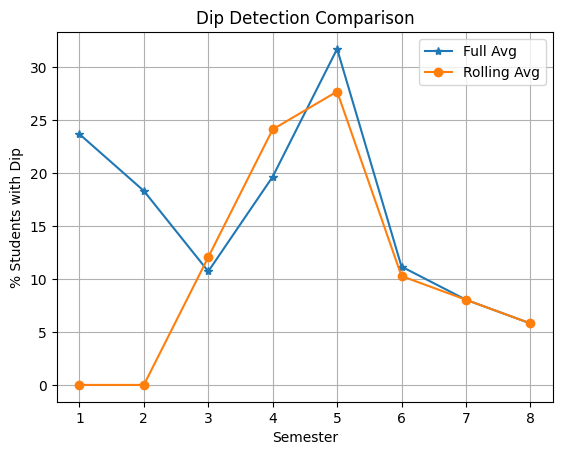

In [175]:
plt.plot(dip_full.index, dip_full, marker='*', label='Full Avg')
plt.plot(dip_roll.index, dip_roll, marker='o', label='Rolling Avg')

plt.title("Dip Detection Comparison")
plt.xlabel("Semester")
plt.ylabel("% Students with Dip")
plt.legend()
plt.grid(True)
plt.show()

# PART 2

# Impact of Question Bank (QB) on Student Performance

#### We analyze student performance before and after the introduction of the Question Bank (QB) in 2022 to understand its impact on SGPA, score consistency, and the distribution of top and low performers.


### WE will find hw SEMESTER WISE Peformance Changed

In [176]:
df.head()

,Student_ID,Student_Name,Batch,Semester,Year,Mid1,Mid2,Internals,EndTerm,Attendance,Total_Marks,SGPA,Performance_Type
0,S0001,Neha Pal,2018,1,2018,5.39,7.29,8.88,58.08,73.8,50.60,4.93,Low_Performer
1,S0001,Neha Pal,2018,2,2018,7.01,7.03,13.11,55.69,68.9,55.00,5.38,Low_Performer
2,S0001,Neha Pal,2018,3,2019,7.35,6.11,8.07,60.64,68.3,51.86,4.94,Low_Performer
3,S0001,Neha Pal,2018,4,2019,5.82,5.71,8.71,52.67,72.9,46.57,4.92,Low_Performer
4,S0001,Neha Pal,2018,5,2020,6.63,4.54,8.52,60.58,71.2,49.98,4.86,Low_Performer


## BATCH BASED Comparison

In this approach, students are grouped based on their admission year (batch) and categorized into Pre-QB and Post-QB groups depending on whether they studied before or after the introduction of the Question Bank in 2022.

This allows us to compare overall performance metrics such as average SGPA, variation, and the proportion of top-performing students between two distinct groups of students.

In [177]:
# QB Era flag — your most important hypothesis variable
df['QB_Era'] = df['Batch'].apply(lambda x: 'Post_QB' if x >= 2022 else 'Pre_QB')

In [178]:
# AVG CGPA
df.groupby('QB_Era')["SGPA"].mean()

QB_Era
Post_QB    7.257102
Pre_QB     6.683772
Name: SGPA, dtype: float64

Post-QB era have a higher average SGPA compared to the Pre-QB era.

In [179]:
# STD CGPA
df.groupby('QB_Era')["SGPA"].std()

QB_Era
Post_QB    1.168804
Pre_QB     1.219739
Name: SGPA, dtype: float64

The variation in scores is slightly lower in POST_QB era

#### TOPPERS percentage

he in Data We had a Column which already States PERFORMANCE_TYPE of Student

In [180]:
df[df['Performance_Type'] == 'Consistent_Topper'].groupby('QB_Era').size() / df.groupby('QB_Era').size() * 100

QB_Era
Post_QB    22.727273
Pre_QB      7.894737
dtype: float64

### Conlusion Based ON BATCH based Analysis

From the batch-based comparison, we observe that students in the---> Post-QB era have a higher average SGPA compared to the Pre-QB era. 
The variation in scores is slightly lower, indicating more consistent performance. 
Additionally, 
    the percentage of top-performing students has increased significantly after the introduction of the Question Bank.



However, this method compares different groups of students and does not account for individual differences or overlapping exposure to both eras. Therefore, while it provides a strong high-level insight, further analysis is required for a more accurate evaluation.

## YEAR BASED comparison 

In [181]:
df["QB_Era_Year"] = df['Year'].apply(lambda x: 'Post_QB' if x >= 2022 else 'Pre_QB' )

# AVG CGPA
df.groupby('QB_Era_Year')["SGPA"].mean()

# STD CGPA
df.groupby("QB_Era_Year")["SGPA"].mean()

QB_Era_Year
Post_QB    7.189303
Pre_QB     6.469982
Name: SGPA, dtype: float64

#### Topper Percentages

In [182]:
df[df["Performance_Type"] == 'Consistent_Topper'].groupby('QB_Era_Year').size()/ df.groupby("QB_Era_Year").size() * 100

QB_Era_Year
Post_QB    18.152350
Pre_QB      8.602151
dtype: float64

### ConClusioon Of YEAR BASED Method

From the year-based comparison, we observe a clear improvement in student performance during the QB era. 
The average SGPA is higher in the Post-QB period, and...
The percentage of top-performing students has increased compared to the Pre-QB period.

This indicates that after the introduction of the Question Bank, student performance improved over time.



#### This is useful because it allows us to compare the same student before and after QB, removing individual differences.

## WITHIN-STUDENT Analysis

In [183]:
#df['QB_Era_Year'] = df['Year'].apply(lambda x: 1 if x >= 2022 else 0)

In [184]:
student_era_avg = df.groupby(['Student_ID', 'QB_Era_Year'])['SGPA'].mean().unstack()

student_era_avg

QB_Era_Year,Post_QB,Pre_QB
Student_ID,,
S0001,NaN,5.15625
S0002,NaN,6.50875
S0003,NaN,7.08625
S0004,NaN,6.34625
S0005,NaN,7.01375
...,...,...
S0220,8.5950,NaN
S0221,7.4575,NaN
S0222,6.7725,NaN


#### KEEPING the Students those who Has Been in BOTH ERA (BEfore and After QB)

In [185]:
student_era_avg = student_era_avg.dropna()
#student_era_avg

In [186]:
# CALCULATING IMPROVEMENT

student_era_avg['Improvement'] = (student_era_avg['Post_QB'] - student_era_avg['Pre_QB'])
#student_era_avg

C:\Users\ani77\AppData\Local\Temp\ipykernel_18680\1119884936.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  student_era_avg['Improvement'] = (student_era_avg['Post_QB'] - student_era_avg['Pre_QB'])


#### IMPROVEMENT Calculation

In [187]:
impv = student_era_avg['Improvement'].mean()
print(f"CPGA improved {impv} points")

CPGA improved 0.5534644194756553 points


In [188]:
# PERCENtaGE of Improvement Students
impv_Student = (student_era_avg['Improvement'] > 0).mean() * 100
print(impv_Student)

78.65168539325843


around 78% of students showed a positive improvement

### Conclusion — Within-Student Analysis

#### By comparing each student’s performance before and after the introduction of the Question Bank, we observe a clear improvement in academic performance. On average, students improved by approximately 0.55 SGPA points. Additionally, around 78% of students showed a positive improvement

Since this method compares each student with their own past performance, it eliminates individual differences and provides the most reliable evidence that the Question Bank had a positive impact on student outcomes.

## IF we Dont have the PERFORMANCE_TYPE in Students dataset,



In the previous analysis, we used the existing Performance_Type labels (such as Consistent_Topper, Average, Low_Performer) to understand patterns in student performance.

However, in real-world scenarios, such predefined labels may not always be available. Therefore, to simulate a more realistic setting, we now remove the Performance_Type column and attempt to derive performance categories directly from the data.

#### we had 2 ways of Doing that,,-->    1) Simple Binning based on the CPGA or Percentile Based (this will split in Equal parts) 
#### ---------------------------------->    2) K-Mean Custering

In [189]:
df.head()

,Student_ID,Student_Name,Batch,Semester,Year,Mid1,Mid2,Internals,EndTerm,Attendance,Total_Marks,SGPA,Performance_Type,QB_Era,QB_Era_Year
0,S0001,Neha Pal,2018,1,2018,5.39,7.29,8.88,58.08,73.8,50.60,4.93,Low_Performer,Pre_QB,Pre_QB
1,S0001,Neha Pal,2018,2,2018,7.01,7.03,13.11,55.69,68.9,55.00,5.38,Low_Performer,Pre_QB,Pre_QB
2,S0001,Neha Pal,2018,3,2019,7.35,6.11,8.07,60.64,68.3,51.86,4.94,Low_Performer,Pre_QB,Pre_QB
3,S0001,Neha Pal,2018,4,2019,5.82,5.71,8.71,52.67,72.9,46.57,4.92,Low_Performer,Pre_QB,Pre_QB
4,S0001,Neha Pal,2018,5,2020,6.63,4.54,8.52,60.58,71.2,49.98,4.86,Low_Performer,Pre_QB,Pre_QB


In [190]:
df_unlabeled = df.copy()
df_unlabeled = df_unlabeled.drop(columns=['Performance_Type'])

In [191]:
df_unlabeled.head()

,Student_ID,Student_Name,Batch,Semester,Year,Mid1,Mid2,Internals,EndTerm,Attendance,Total_Marks,SGPA,QB_Era,QB_Era_Year
0,S0001,Neha Pal,2018,1,2018,5.39,7.29,8.88,58.08,73.8,50.60,4.93,Pre_QB,Pre_QB
1,S0001,Neha Pal,2018,2,2018,7.01,7.03,13.11,55.69,68.9,55.00,5.38,Pre_QB,Pre_QB
2,S0001,Neha Pal,2018,3,2019,7.35,6.11,8.07,60.64,68.3,51.86,4.94,Pre_QB,Pre_QB
3,S0001,Neha Pal,2018,4,2019,5.82,5.71,8.71,52.67,72.9,46.57,4.92,Pre_QB,Pre_QB
4,S0001,Neha Pal,2018,5,2020,6.63,4.54,8.52,60.58,71.2,49.98,4.86,Pre_QB,Pre_QB


### Labeliing Students BAsed ON their OVERALL Performance

In [192]:
df_student = df_unlabeled.groupby('Student_ID')['SGPA'].mean().to_frame()

df_student['Perf_Label'] = pd.qcut(
    df_student['SGPA'],
    q=4,
    labels=['Low', 'Below_Avg', 'Above_Avg', 'Topper']
)

In [193]:
df_student

,SGPA,Perf_Label
Student_ID,,
S0001,5.15625,Low
S0002,6.50875,Low
S0003,7.08625,Above_Avg
S0004,6.34625,Low
S0005,7.01375,Below_Avg
...,...,...
S0220,8.59500,Topper
S0221,7.45750,Topper
S0222,6.77250,Below_Avg


### SEtting UP for K-MEAN

In [194]:
df_wide = df_unlabeled.pivot_table(
    index='Student_ID',
    columns='Semester',
    values='SGPA'
)

In [195]:
df_wide.columns = [f'S{int(c)}' for c in df_wide.columns]
df_wide = df_wide.reset_index()

df_wide.head()

,Student_ID,S1,S2,S3,S4,S5,S6,S7,S8
0,S0001,4.93,5.38,4.94,4.92,4.86,5.59,6.17,4.46
1,S0002,6.65,6.77,6.08,5.38,6.79,6.94,7.49,5.97
2,S0003,8.03,6.77,6.60,7.59,5.90,7.34,7.14,7.32
3,S0004,6.29,5.58,6.21,6.93,5.12,5.62,7.90,7.12
4,S0005,6.26,6.95,8.54,7.73,6.37,6.14,6.83,7.29


In [196]:
static = df.drop_duplicates('Student_ID')[
    ['Student_ID', 'Batch', 'Performance_Type', 'QB_Era']
]

df_wide = df_wide.merge(static, on='Student_ID')

df_wide.head()

,Student_ID,S1,S2,S3,S4,S5,S6,S7,S8,Batch,Performance_Type,QB_Era
0,S0001,4.93,5.38,4.94,4.92,4.86,5.59,6.17,4.46,2018,Low_Performer,Pre_QB
1,S0002,6.65,6.77,6.08,5.38,6.79,6.94,7.49,5.97,2018,Average,Pre_QB
2,S0003,8.03,6.77,6.60,7.59,5.90,7.34,7.14,7.32,2018,Average,Pre_QB
3,S0004,6.29,5.58,6.21,6.93,5.12,5.62,7.90,7.12,2018,Average,Pre_QB
4,S0005,6.26,6.95,8.54,7.73,6.37,6.14,6.83,7.29,2018,Average,Pre_QB


In [197]:
df_wide.isnull().sum()

Student_ID          0
S1                  0
S2                  0
S3                  0
S4                  0
S5                  0
S6                  0
S7                  0
S8                  0
Batch               0
Performance_Type    0
QB_Era              0
dtype: int64

In [198]:
df_kmeans = df_wide.dropna(
    subset=['S1','S2','S3','S4','S5','S6','S7','S8']
)

print("Students used:", len(df_kmeans))


Students used: 224


In [199]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [200]:
features = ['S1','S2','S3','S4','S5','S6','S7','S8']
X = df_kmeans[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [201]:
kmeans = KMeans(n_clusters=4, random_state=42)

df_kmeans['Cluster'] = kmeans.fit_predict(X_scaled)

df_kmeans.head()

,Student_ID,S1,S2,S3,S4,S5,S6,S7,S8,Batch,Performance_Type,QB_Era,Cluster
0,S0001,4.93,5.38,4.94,4.92,4.86,5.59,6.17,4.46,2018,Low_Performer,Pre_QB,2
1,S0002,6.65,6.77,6.08,5.38,6.79,6.94,7.49,5.97,2018,Average,Pre_QB,1
2,S0003,8.03,6.77,6.60,7.59,5.90,7.34,7.14,7.32,2018,Average,Pre_QB,1
3,S0004,6.29,5.58,6.21,6.93,5.12,5.62,7.90,7.12,2018,Average,Pre_QB,0
4,S0005,6.26,6.95,8.54,7.73,6.37,6.14,6.83,7.29,2018,Average,Pre_QB,1


In [202]:
pd.crosstab(df_kmeans['Performance_Type'], df_kmeans['Cluster'])

Cluster,0,1,2,3
Performance_Type,,,,
Average,16,105,1,0
Consistent_Topper,0,0,0,34
Late_Bloomer,28,0,0,0
Low_Performer,1,0,39,0


In [203]:
from sklearn.metrics import adjusted_rand_score

label_map = {0: 'Late_Bloomer', 1: 'Average', 2: 'Low_Performer', 3: 'Consistent_Topper'}
df_kmeans['Cluster_Label'] = df_kmeans['Cluster'].map(label_map)

score = adjusted_rand_score(df_kmeans['Performance_Type'], df_kmeans['Cluster_Label'])
print(f"Adjusted Rand Score: {score:.3f}")

Adjusted Rand Score: 0.789


In [204]:
df_kmeans

,Student_ID,S1,S2,S3,S4,S5,S6,S7,S8,Batch,Performance_Type,QB_Era,Cluster,Cluster_Label
0,S0001,4.93,5.38,4.94,4.92,4.86,5.59,6.17,4.46,2018,Low_Performer,Pre_QB,2,Low_Performer
1,S0002,6.65,6.77,6.08,5.38,6.79,6.94,7.49,5.97,2018,Average,Pre_QB,1,Average
2,S0003,8.03,6.77,6.60,7.59,5.90,7.34,7.14,7.32,2018,Average,Pre_QB,1,Average
3,S0004,6.29,5.58,6.21,6.93,5.12,5.62,7.90,7.12,2018,Average,Pre_QB,0,Late_Bloomer
4,S0005,6.26,6.95,8.54,7.73,6.37,6.14,6.83,7.29,2018,Average,Pre_QB,1,Average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,S0220,8.34,9.32,9.07,8.46,8.02,8.16,8.75,8.64,2025,Consistent_Topper,Post_QB,3,Consistent_Topper
220,S0221,7.85,8.01,7.92,6.67,7.47,6.42,8.17,7.15,2025,Average,Post_QB,1,Average
221,S0222,6.28,7.14,7.67,6.45,6.09,7.06,6.09,7.40,2025,Average,Post_QB,1,Average
222,S0223,6.20,7.23,8.37,7.30,6.84,7.21,6.95,7.00,2025,Average,Post_QB,1,Average


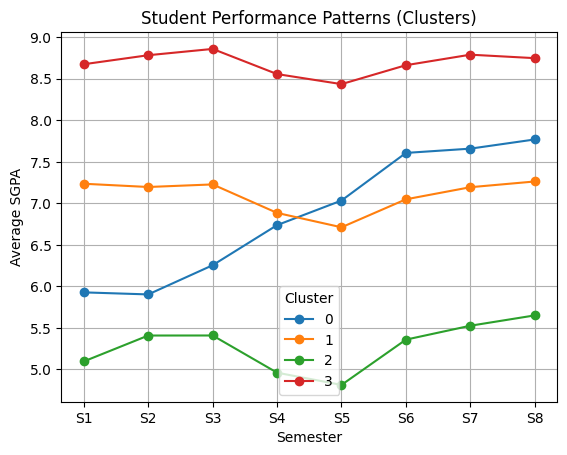

In [205]:
import matplotlib.pyplot as plt

cluster_means = df_kmeans.groupby('Cluster')[['S1','S2','S3','S4','S5','S6','S7','S8']].mean()

cluster_means.T.plot(marker='o')

plt.title("Student Performance Patterns (Clusters)")
plt.xlabel("Semester")
plt.ylabel("Average SGPA")
plt.legend(title="Cluster")
plt.grid(True)

plt.show()

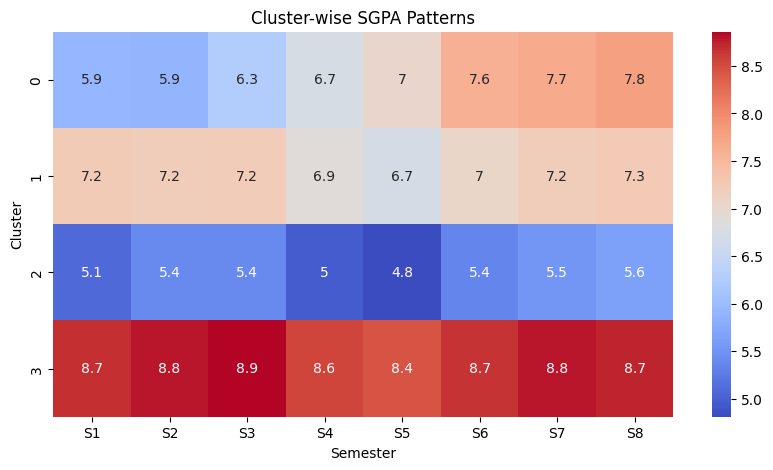

In [206]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.heatmap(cluster_means, annot=True, cmap='coolwarm')

plt.title("Cluster-wise SGPA Patterns")
plt.xlabel("Semester")
plt.ylabel("Cluster")

plt.show()

In [207]:
# Who are the 'Average' students sitting in the Late Bloomer cluster?
mixed = df_kmeans[(df_kmeans['Cluster'] == 0) & (df_kmeans['Performance_Type'] == 'Average')]

print(mixed[['S1','S2','S3','S4','S5','S6','S7','S8']].mean().round(2))
# Compare with actual Late Bloomers
late = df_kmeans[df_kmeans['Performance_Type'] == 'Late_Bloomer']
print(late[['S1','S2','S3','S4','S5','S6','S7','S8']].mean().round(2))

S1    6.30
S2    6.23
S3    6.44
S4    6.61
S5    6.50
S6    7.22
S7    7.47
S8    7.46
dtype: float64
S1    5.73
S2    5.73
S3    6.17
S4    6.84
S5    7.38
S6    7.87
S7    7.77
S8    7.97
dtype: float64


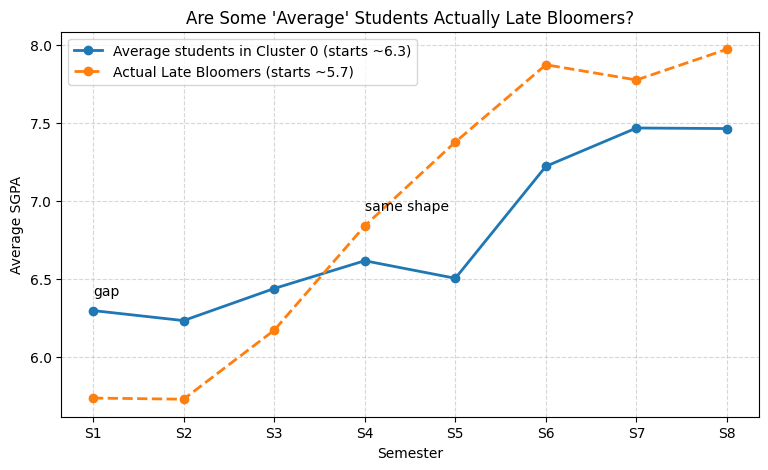

In [208]:


mixed_mean = mixed[['S1','S2','S3','S4','S5','S6','S7','S8']].mean()
late_mean = late[['S1','S2','S3','S4','S5','S6','S7','S8']].mean()

plt.figure(figsize=(9,5))

# Yellow line (Average in LB cluster)
plt.plot(mixed_mean.index, mixed_mean.values,
         marker='o', linewidth=2,
         label='Average students in Cluster 0 (starts ~6.3)')

# Red dashed line (Actual Late Bloomers)
plt.plot(late_mean.index, late_mean.values,
         marker='o', linestyle='--', linewidth=2,
         label='Actual Late Bloomers (starts ~5.7)')

# Title & labels
plt.title("Are Some 'Average' Students Actually Late Bloomers?")
plt.xlabel("Semester")
plt.ylabel("Average SGPA")

# Add annotations (THIS is what makes your graph cool)
plt.text('S1', mixed_mean.values[0]+0.1, 'gap', fontsize=10)
plt.text('S4', late_mean.values[3]+0.1, 'same shape', fontsize=10)

# Grid & legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()